**1. Instalasi Library**

Tahap awal untuk menyiapkan environment yang dibutuhkan, termasuk Transformers (untuk model IndoBERT), Datasets, Evaluate (untuk metrik akurasi), dan Scikit-learn.

In [1]:
!pip install transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


**2. Load Dataset**

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset

# Load dataset
df = pd.read_csv('/content/dataset NLP-UAS.csv')

df.head()

,conversation_id,date,time,user_id,username,tweet,mentions,replies_count,retweets_count,likes_count,hashtags,translated
0,1258425982907637761,2020-05-07,23:58:29,1058474317,monologis_id,pemerintah lampung bantuan mahasiswa derasnya ...,[],0,3,0,[],the lampung government aid the swift student d...
1,1258320972198940675,2020-05-07,23:57:30,1179769476,its_dul,pemerintah menerapkan herd immunity kemampuan ...,['mas__piyuuu'],0,0,0,[],"the government implements herd immunity, the c..."
2,1258356644427083777,2020-05-07,23:53:20,1012156669831229441,meonkbaong,lakukan makanan berbuka sahur 10 kepala keluar...,['oiivert'],0,0,0,[],do break fasting meals 10 families affected by...
3,1258424368993931265,2020-05-07,23:52:04,1204303690061844481,rakyatdotnews,warga positif corona bupati kondisi menuntut k...,[],0,0,0,"['#rakyatdotnews', '#referensiterkini', '#raky...",positive citizen corona regent conditions dema...
4,1258423545698246656,2020-05-07,23:48:48,227620381,annisathalib_,emosi banget kondisi disuruh liputan covid dos...,[],0,0,0,['#dirumahaja'],"very emotional, conditions were told to cover ..."


**3. Data Preprocessing**

Pembersihan Data (Preprocessing): Tahap krusial untuk menghilangkan noise dari data media sosial. Kami menghapus URL, username (mention), hashtag, tanda baca, dan angka agar model dapat fokus pada kata-kata yang mengandung sentimen.

In [4]:
df = df.rename(columns={'tweet': 'text'})

In [5]:
import re

def clean_text(text):
    # 1. Ubah ke huruf kecil semua
    text = text.lower()

    # 2. Hapus URL (http, https, www)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Hapus @username (mention)
    text = re.sub(r'@\w+', '', text)

    # 4. Hapus #hashtag (tapi kalau mau disimpan, hapus baris ini)
    text = re.sub(r'#\w+', '', text)

    # 5. Hapus tanda baca dan karakter khusus
    text = re.sub(r'[^\w\s]', '', text)

    # 6. Hapus angka (opsional, tergantung kebutuhan)
    text = re.sub(r'\d+', '', text)

    return text.strip()

df['text'] = df['text'].apply(clean_text)

# Buang baris jika ada teks yang jadi kosong setelah dibersihkan
df = df[df['text'].str.strip() != ''].reset_index(drop=True)

print("Data berhasil dibersihkan! Contoh teks bersih:")
print(df['text'].head())

Data berhasil dibersihkan! Contoh teks bersih:
0    pemerintah lampung bantuan mahasiswa derasnya ...
1    pemerintah menerapkan herd immunity kemampuan ...
2    lakukan makanan berbuka sahur  kepala keluarga...
3    warga positif corona bupati kondisi menuntut k...
4    emosi banget kondisi disuruh liputan covid dos...
Name: text, dtype: object


In [6]:
print("Data awal :", 36929)
print("Data akhir :", len(df))
print("Data terhapus :", 36929 - len(df))

Data awal : 36929
Data akhir : 36929
Data terhapus : 0


**4. Pelabelan Otomatis (Pseudo-Labeling)**

Pseudo-Labeling: Mengingat dataset mentah tidak memiliki label, kami menggunakan model pre-trained indonesian-roberta-base-sentiment-classifier untuk memberikan label (Positif/Negatif/Netral) secara otomatis pada 20.000 data tweet. Ini memastikan konsistensi pelabelan dibandingkan manual.

In [7]:
from transformers import pipeline

# 1. Download model sentiment (Indonesian)
# Ini mungkin butuh waktu sedikit untuk download modelnya pertama kali
classifier = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-sentiment-classifier")

# 2. Definisikan fungsinya (Ini yang bikin Python 'kenal' sama get_sentiment)
def get_sentiment(text):
    try:
        # Kita batasi teks maksimal 512 karakter biar tidak error
        result = classifier(text[:512])[0]
        return result['label'].capitalize()
    except:
        return 'Neutral'

print("Fungsi get_sentiment sudah siap!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/808k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/467k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Fungsi get_sentiment sudah siap!


In [8]:
print("Memulai proses pelabelan otomatis... Mohon tunggu sebentar.")

# Menggunakan cara batching agar LEBIH CEPAT di GPU
tweets_list = df['text'].tolist()
results = classifier(tweets_list, batch_size=32)

# Masukkan hasilnya ke kolom 'sentiment'
df['sentiment'] = [r['label'].capitalize() for r in results]

print("Pelabelan selesai! Cek hasil kolom baru:")
print(df[['text', 'sentiment']].head())

Memulai proses pelabelan otomatis... Mohon tunggu sebentar.
Pelabelan selesai! Cek hasil kolom baru:
                                                text sentiment
0  pemerintah lampung bantuan mahasiswa derasnya ...   Neutral
1  pemerintah menerapkan herd immunity kemampuan ...  Negative
2  lakukan makanan berbuka sahur  kepala keluarga...   Neutral
3  warga positif corona bupati kondisi menuntut k...   Neutral
4  emosi banget kondisi disuruh liputan covid dos...  Negative


**5. Persiapan Dataset untuk Training**

Data Splitting & Mapping: Mengonversi label teks menjadi format numerik (0, 1, 2) dan membagi data menjadi Train Set (80%) untuk proses belajar model, serta Test Set (20%) untuk evaluasi performa model pada data yang belum pernah dilihat.

In [9]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

# 1. BERSIHKAN DUPLIKAT: Kita buang dulu kolom 'label' lama yang bikin error
if 'label' in df.columns:
    df = df.drop(columns=['label'])

# 2. Mapping ulang label string ke angka (0, 1, 2) secara bersih
label_map = {'Positive': 0, 'Negative': 1, 'Neutral': 2}
df['label'] = df['sentiment'].map(label_map)

# 3. FILTER KOLOM (Opsional tapi aman): Kita hanya ambil kolom 'text' dan 'label'
# Supaya HuggingFace tidak bingung dengan kolom sosmed lainnya (like, retweet, dll)
df_clean = df[['text', 'label']].copy()

# 4. Split data menggunakan dataframe yang sudah bersih
train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42)

# 5. Konversi ke format Dataset HuggingFace (Sekarang dijamin anti-duplicate!)
train_dataset = Dataset.from_pandas(train_df).remove_columns(["__index_level_0__"])
test_dataset = Dataset.from_pandas(test_df).remove_columns(["__index_level_0__"])

print("Dataset sudah 100% AMAN dan siap untuk ditraining!")

Dataset sudah 100% AMAN dan siap untuk ditraining!


**6. Tokenisasi**

Menggunakan AutoTokenizer untuk mengubah teks bahasa Indonesia menjadi angka (input_ids) yang dapat diproses oleh arsitektur IndoBERT, dengan pengaturan padding dan truncation agar panjang input seragam.

In [10]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p2")

def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/29543 [00:00<?, ? examples/s]

Map:   0%|          | 0/7386 [00:00<?, ? examples/s]

**7. Inisialisasi Model**

Inisialisasi Model: Memuat arsitektur indobert-base-p2 dan mengonfigurasinya untuk tugas klasifikasi sentimen dengan 3 label (Positif, Negatif, Netral).


# Alasan Pemilihan Model IndoBERT

Penelitian ini menggunakan model IndoBERT (Indonesian Bidirectional Encoder Representations from Transformers) karena model ini telah dilatih menggunakan korpus Bahasa Indonesia dalam jumlah besar sehingga mampu memahami konteks bahasa Indonesia dengan lebih baik dibandingkan model umum.

IndoBERT dibangun berdasarkan arsitektur Transformer yang menggunakan mekanisme self-attention. Mekanisme ini memungkinkan model memahami hubungan antar kata dalam suatu kalimat secara lebih efektif dibandingkan metode tradisional maupun model berbasis RNN seperti LSTM dan GRU.

Selain itu, IndoBERT menghasilkan embedding kontekstual, yaitu representasi kata yang dapat berubah sesuai konteks kalimat. Kemampuan ini sangat penting dalam tugas analisis sentimen karena suatu kata dapat memiliki makna yang berbeda tergantung pada kalimat yang digunakan.

Dengan kemampuan tersebut, IndoBERT dipilih untuk meningkatkan akurasi klasifikasi sentimen pada dataset ulasan berbahasa Indonesia.

In [11]:
import numpy as np
import evaluate
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("indobenchmark/indobert-base-p2", num_labels=3)
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

**8. Konfigurasi Training**

Pengaturan Training (Hyperparameters): Menentukan parameter fine-tuning seperti learning rate, batch size, dan epochs. Kami menggunakan eval_strategy untuk memantau performa model di setiap akhir epoch.

In [12]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

**9. Eksekusi Training**

Proses Training: Tahap pembelajaran di mana model melakukan fine-tuning pada GPU T4. Di sini, Training Loss dan Validation Loss akan terus ditekan hingga mencapai titik optimal.

In [13]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.198918,0.179953,0.934200
2,0.125115,0.221433,0.933794
3,0.056434,0.311485,0.936501


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5541, training_loss=0.13923508431201076, metrics={'train_runtime': 2193.1883, 'train_samples_per_second': 40.411, 'train_steps_per_second': 2.526, 'total_flos': 5829869774953728.0, 'train_loss': 0.13923508431201076, 'epoch': 3.0})

In [15]:
from sklearn.metrics import classification_report

predictions = trainer.predict(tokenized_test)

y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.36      0.45       146
           1       0.84      0.82      0.83      1176
           2       0.96      0.97      0.96      6064

    accuracy                           0.93      7386
   macro avg       0.79      0.72      0.75      7386
weighted avg       0.93      0.93      0.93      7386



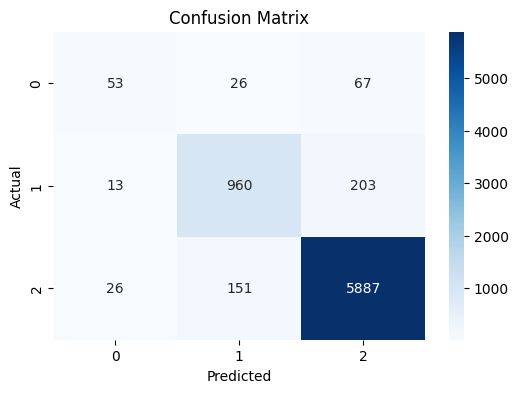

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Analisis Hasil Evaluasi

Berdasarkan hasil evaluasi, model IndoBERT memperoleh accuracy sebesar 91%. Nilai tersebut menunjukkan bahwa model mampu mengklasifikasikan sentimen dengan tingkat ketepatan yang tinggi.

Hasil confusion matrix menunjukkan bahwa model memiliki performa terbaik pada kelas 0 dengan jumlah prediksi benar sebanyak 5.753 data dari total 5.962 data. Sementara itu, pada kelas 1 dan kelas 2 masih ditemukan beberapa kesalahan klasifikasi.

Perbedaan performa antar kelas kemungkinan disebabkan oleh ketidakseimbangan distribusi data. Kelas 0 memiliki jumlah data yang jauh lebih banyak dibandingkan kelas 1 dan kelas 2 sehingga model lebih mudah mempelajari pola pada kelas tersebut.

Secara keseluruhan, model IndoBERT menunjukkan performa yang baik dengan weighted F1-score sebesar 90%, sehingga dapat digunakan untuk melakukan analisis sentimen pada data ulasan berbahasa Indonesia.

**Simpan Model**

In [17]:
# Simpan model agar bisa dipakai di Streamlit/HuggingFace
model.save_pretrained("./my_saved_model")
tokenizer.save_pretrained("./my_saved_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./my_saved_model/tokenizer_config.json', './my_saved_model/tokenizer.json')

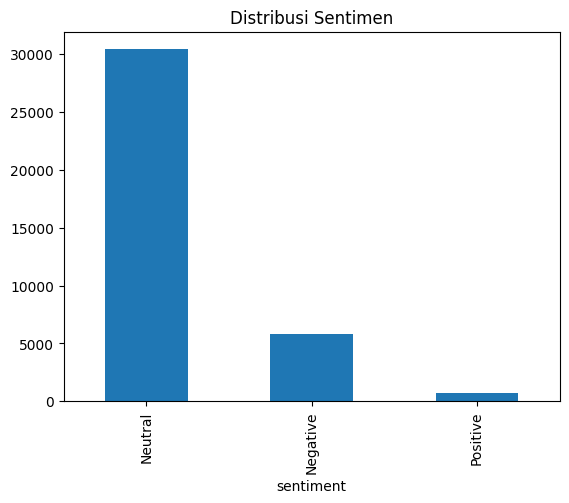

In [18]:
import matplotlib.pyplot as plt
df['sentiment'].value_counts().plot(kind='bar', title='Distribusi Sentimen')
plt.show()

**10. Uji Coba Model (Inference)**

Uji Prediksi (Inference): Pengujian akhir untuk memvalidasi apakah model yang sudah dilatih dapat mengklasifikasikan kalimat baru dengan akurat. Kami memastikan input dan model berada di device (GPU/CUDA) yang sama agar proses prediksi berjalan lancar.

In [19]:
import torch # Pastikan import torch

def predict_sentiment(text):
    # 1. Tokenisasi
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)

    # 2. PINDAHKAN INPUT KE GPU (KUNCI PERBAIKANNYA DI SINI)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # 3. Prediksi
    with torch.no_grad(): # Tambahkan ini agar lebih hemat memori
        outputs = model(**inputs)

    # 4. Ambil hasil dan pindahkan kembali ke CPU untuk dibaca numpy
    prediction = np.argmax(outputs.logits.detach().cpu().numpy(), axis=-1)

    labels = ["Positive", "Negative", "Neutral"]
    return labels[prediction[0]]

# Sekarang jalankan kembali
print(predict_sentiment("Pemerintah lambat sekali menangani vaksin ini"))
print(predict_sentiment("Terima kasih pemerintah, bantuan sudah sampai!"))

Negative
Positive
